<a href="https://colab.research.google.com/github/AaravJain626/ML-DL-using-PyTorch/blob/main/Computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Computer Vision Using PyTorch

In [ ]:
import torch
from torch import nn

#import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)


2.10.0+cpu
0.25.0+cpu


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

##1.Getting  data
fashion MNIST from torchvision.datasets


In [ ]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 21.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 342kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.31MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.2MB/s]


In [ ]:
len(test_data),len(train_data)

(10000, 60000)

In [ ]:
image,label = train_data[0]
# image,label

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
image.shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, '5')

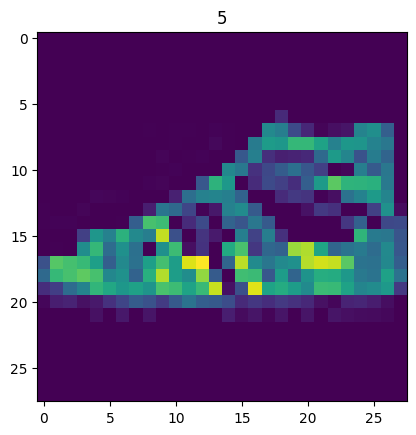

In [ ]:
image,label = train_data[7028]
plt.imshow(image.squeeze())
plt.title(label)

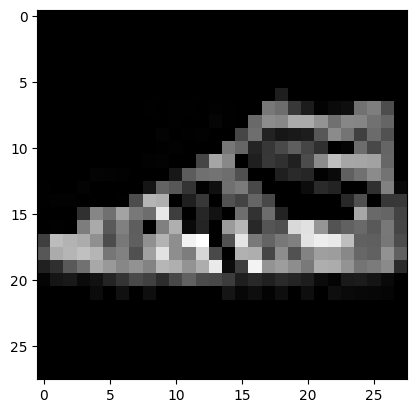

In [ ]:
plt.imshow(image.squeeze(),cmap="gray")

##2.Making Dataloader

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              )
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

In [ ]:
train_dataloader.batch_sampler

In [ ]:
print(f"DataLoaders:{train_dataloader,test_dataloader}")
print(f"Length of train_dataloader{len(train_dataloader)} Batches of {BATCH_SIZE}")
print(f"Length of test_dataloader:{len(test_dataloader)} Batches of {BATCH_SIZE}")


DataLoaders:(<torch.utils.data.dataloader.DataLoader object at 0x7adcc17a1760>, <torch.utils.data.dataloader.DataLoader object at 0x7adcc18a6090>)
Length of train_dataloader1875 Batches of 32
Length of test_dataloader:313 Batches of 32


In [ ]:
#whats inside the dataloader
train_features_batch,train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

## 3.Model 0:Building a Baseline model

In [ ]:
#Create a Flatten layer
flatten_model = nn.Flatten()

# single sample
x =train_features_batch[0]

#flatten the sample
output = flatten_model(x)

print(f"shape before flattening:{x.shape}->color chanel,height,width")
print(f"shape after flattening:{output.shape}->color channel,height*width")

shape before flattening:torch.Size([1, 28, 28])->color chanel,height,width
shape after flattening:torch.Size([1, 784])->color channel,height*width


In [ ]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
              input_shape: int,
              hidden_units: int,
              output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)

    )
  def forward(self, x):
    return self.layer_stack(x)


In [ ]:
torch.manual_seed(42)

#Setting up model with input params
model_0 = FashionMNISTModelV0(
    input_shape=784,#=28*28
    hidden_units=10,#units in Hidden layer
    output_shape=len(class_names)
).to("cpu")


In [ ]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

###3.1 Loss,optimizer and evaluation

In [ ]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("Condition Satisfied.")
else:
  ("Initializing Download.")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

In [ ]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """Prints difference between start and end time."""
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time


In [ ]:
start_time =  timer()
#code blob
end_time = timer()
print_train_time(start=start_time, end=end_time, device = "cpu")

Train time on cpu: 0.000 seconds


3.4779000003482e-05

###3.3 Creating a Training Loop and training the model on batches

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3

#Creating training and test loop
for epoch in tqdm(range(epochs)):
  #Training
  train_loss = 0
  #Adding a loop through training batches
  for batch, (X,y) in enumerate(train_dataloader):
    model_0.train()

    #Forward pass
    y_pred = model_0(X)

    #Loss(p.bath)
    loss = loss_fn(y_pred,y)
    train_loss += loss

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} sampsl")
  train_loss /= len(train_dataloader)

  #Testing
  test_loss,test_acc = 0,0
  model_0.eval()
  with torch.inference_mode():
    for X_test,y_test in test_dataloader:
      #Forward Pass
      test_pred =  model_0(X_test)

      #loss
      test_loss += loss_fn(test_pred,y_test)

      #Calc Acc
      test_acc += accuracy_fn(y_true=y_test,
                              y_pred=test_pred.argmax(dim=1))
    #calculate the av test loss P.B
    test_loss /= len(test_dataloader)

    test_acc /= len(test_dataloader)
  print(f"\nTrainLoss:{train_loss:.4f}|Test Loss:{test_loss:.4f},Test Acc:{test_acc:.4f}")
  train_time_end_on_cpu = timer()
  total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                             end=train_time_end_on_cpu,
                                              device=str(next(model_0.parameters())))

  0%|          | 0/3 [00:00<?, ?it/s]

Looked at 0/60000 sampsl
Looked at 12800/60000 sampsl
Looked at 25600/60000 sampsl
Looked at 38400/60000 sampsl
Looked at 51200/60000 sampsl

TrainLoss:0.4041|Test Loss:0.4549,Test Acc:84.1653
Train time on Parameter containing:
tensor([[ 2.7300e-02,  3.1195e-02,  8.0225e-03,  ...,  1.1391e-01,
          3.6076e-02,  3.4365e-02],
        [-1.9802e-02, -3.7026e-02,  1.1140e-04,  ...,  1.2052e-01,
          4.3884e-02,  6.9969e-03],
        [-9.0267e-04,  2.7007e-03, -3.6063e-03,  ...,  5.2416e-02,
         -3.5969e-02,  1.3372e-02],
        ...,
        [-1.1316e-02,  2.8516e-02, -1.9195e-02,  ...,  1.1657e-01,
          1.1817e-01,  3.7574e-03],
        [-2.3710e-02,  2.2620e-02, -5.6749e-03,  ..., -1.8652e-01,
         -6.0166e-02, -2.4483e-02],
        [ 1.6459e-02, -1.7139e-02, -1.6639e-02,  ..., -2.6601e-01,
         -2.2939e-01, -1.5269e-02]], requires_grad=True): 10.114 seconds
Looked at 0/60000 sampsl
Looked at 12800/60000 sampsl
Looked at 25600/60000 sampsl
Looked at 38400/6000

##4. Make Preds AND   GET model 0 results


In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """returns a dict having resulst on model predicting on data_loader"""
  loss,acc = 0,0
  model_eval()
  with torch.inference_mode():
    for X,y in data_loader:
      # make preds
      y_pred = model(X)

      #loss and acc per batch
      loss += loss_fn